<a href="https://colab.research.google.com/github/Asaf21S/flow-matching-as-a-layer/blob/main/notebooks/classifiers_baselines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Stage 1: Classification Baselines

This notebook implements and evaluates the Stage 1 classification baselines on frozen pretrained image encoders:

- **Datasets & Protocol**: DTD (47 classes, partition 1) and FGVC-Aircraft (100 classes, variant level). Uses official train, validation, and test splits ($K \in \{5, 10, \text{full}\}$ training images per class with seeds $\{0, 1, 2\}$).
- **Frozen Encoders**: ResNet-18 (ImageNet-1K, 512-dim), DINOv2 ViT-S/14 (384-dim), and CLIP RN50 (1024-dim).
- **Baselines**: Mandatory **Softmax Linear Probing** ($s = Wz + b$, AdamW optimizer) and **Option B: Zero-Shot CLIP** (text-derived prototypes).
- **Deliverables**: Top-1 accuracy summary table, accuracy vs. $K$ plots with error bars, linear probe training curves, row-normalized confusion matrices, and 2D feature projections (PCA & t-SNE).

## 1. Setup & Environment

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import os
import sys
import logging
import warnings
from pathlib import Path

# Suppress noisy library warnings
warnings.filterwarnings("ignore")
os.environ["HF_HUB_DISABLE_SYMLINKS_WARNING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
logging.getLogger("huggingface_hub").setLevel(logging.ERROR)
logging.getLogger("transformers").setLevel(logging.ERROR)
logging.getLogger("matplotlib").setLevel(logging.ERROR)

import torch

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    if not os.path.exists("/content/flow-matching-as-a-layer"):
        !git clone https://github.com/Asaf21S/flow-matching-as-a-layer.git
    %cd /content/flow-matching-as-a-layer
    !git pull --ff-only
    !pip install -q -r requirements-colab.txt

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent

DATA_ROOT = REPO_ROOT / "data"
FEATURE_ROOT = REPO_ROOT / "features"
RESULTS_ROOT = REPO_ROOT / "results"

for path in (DATA_ROOT, FEATURE_ROOT, RESULTS_ROOT):
    path.mkdir(parents=True, exist_ok=True)

os.environ["FMLAYER_DATA_ROOT"] = str(DATA_ROOT)
os.environ["FMLAYER_FEATURE_ROOT"] = str(FEATURE_ROOT)
os.environ["FMLAYER_RESULTS_ROOT"] = str(RESULTS_ROOT)

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Environment: {'Colab' if IN_COLAB else 'Local'}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Environment: Local
PyTorch: 2.13.0+cu130 | CUDA: True


## 2. Dataset Preparation

In [2]:
from src.fmlayer.data.prepare import prepare_datasets

report = prepare_datasets()
for key, info in report["datasets"].items():
    print(f"{info['display_name']} ({info['num_classes']} classes): ready.")

Data root: /home/ordinary/projects/flow-matching-as-a-layer/data

=== FGVC-Aircraft (aircraft) ===
    protocol: {'annotation_level': 'variant'}, approx. 2750 MB
    [ok] train   3334 images, 100 classes, 33-34 per class
    [ok] val     3333 images, 100 classes, 33-34 per class
    [ok] test    3333 images, 100 classes, 33-34 per class
    prompt: 'a photo of a 707-320 aircraft' ... 'a photo of a Yak-42 aircraft'
=== DTD (dtd) ===
    protocol: {'partition': 1}, approx. 625 MB
    [ok] train   1880 images, 47 classes, 40-40 per class
    [ok] val     1880 images, 47 classes, 40-40 per class
    [ok] test    1880 images, 47 classes, 40-40 per class
    prompt: 'a photo of a banded texture' ... 'a photo of a zigzagged texture'
FGVC-Aircraft (100 classes): ready.
DTD (47 classes): ready.


## 3. Pretrained Encoders & Feature Extraction

In [3]:
from src.fmlayer.encoders.check import smoke_test_encoders
from src.fmlayer.features.extract import extract_all

smoke_test_encoders()
cached_paths = extract_all()
print(f"Cached feature splits across {len(cached_paths)} files.")

Device: cuda

[ok] resnet18       input (3, 224, 224) -> features (2, 512)


Using cache found in /home/ordinary/.cache/torch/hub/facebookresearch_dinov2_main


[ok] dinov2_vits14  input (3, 224, 224) -> features (2, 384)


[ok] clip_rn50      input (3, 224, 224) -> features (2, 1024)
                    text prompts -> (2, 1024)
Device: cuda

=== resnet18 ===
    [cached] resnet18/dtd/train -> dtd_train.npz
    [cached] resnet18/dtd/val -> dtd_val.npz
    [cached] resnet18/dtd/test -> dtd_test.npz
    [cached] resnet18/aircraft/train -> aircraft_train.npz
    [cached] resnet18/aircraft/val -> aircraft_val.npz
    [cached] resnet18/aircraft/test -> aircraft_test.npz

=== dinov2_vits14 ===


Using cache found in /home/ordinary/.cache/torch/hub/facebookresearch_dinov2_main


    [cached] dinov2_vits14/dtd/train -> dtd_train.npz
    [cached] dinov2_vits14/dtd/val -> dtd_val.npz
    [cached] dinov2_vits14/dtd/test -> dtd_test.npz

=== clip_rn50 ===
    [cached] clip_rn50/dtd/train -> dtd_train.npz
    [cached] clip_rn50/dtd/val -> dtd_val.npz
    [cached] clip_rn50/dtd/test -> dtd_test.npz
    [cached] clip_rn50/dtd/text -> dtd_text.npz
    [cached] clip_rn50/aircraft/train -> aircraft_train.npz
    [cached] clip_rn50/aircraft/val -> aircraft_val.npz
    [cached] clip_rn50/aircraft/test -> aircraft_test.npz
    [cached] clip_rn50/aircraft/text -> aircraft_text.npz

17 feature files ready.
Cached feature splits across 17 files.


## 4. Option B Baseline: Zero-Shot CLIP

In [4]:
from src.fmlayer.models.zeroshot import run_zeroshot_all

zeroshot_results = run_zeroshot_all()

[FGVC-Aircraft] zero-shot CLIP RN50: 0.1554 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'
[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'


## 5. Subsets & Linear Probe Baseline

In [5]:
from src.fmlayer.data.fewshot import build_all_subsets
from src.fmlayer.train.train_linear import run_all_linear_probes

build_all_subsets()
probe_results = run_all_linear_probes()


=== dtd (1880 training images, 47 classes) ===
    k=5    seed=0    235 images, 5-5 per class
    k=5    seed=1    235 images, 5-5 per class
    k=5    seed=2    235 images, 5-5 per class
    k=10   seed=0    470 images, 10-10 per class
    k=10   seed=1    470 images, 10-10 per class
    k=10   seed=2    470 images, 10-10 per class
    k=full seed=0   1880 images, 40-40 per class

=== aircraft (3334 training images, 100 classes) ===
    k=5    seed=0    500 images, 5-5 per class
    k=5    seed=1    500 images, 5-5 per class
    k=5    seed=2    500 images, 5-5 per class
    k=10   seed=0   1000 images, 10-10 per class
    k=10   seed=1   1000 images, 10-10 per class
    k=10   seed=2   1000 images, 10-10 per class
    k=full seed=0   3334 images, 33-34 per class
Device: cuda


linear probes:   4%|▎         | 1/27 [00:00<00:11,  2.30it/s]

    resnet18       dtd       k=5    seed=0  train=  235  val=0.4489@125  test=0.4628


linear probes:   7%|▋         | 2/27 [00:00<00:09,  2.55it/s]

    resnet18       dtd       k=5    seed=1  train=  235  val=0.4559@32   test=0.4426


...

    dinov2_vits14  dtd       k=full seed=0  train= 1880  val=0.7596@12   test=0.7569


linear probes:  96%|█████████▋| 26/27 [00:35<00:01,  1.58s/it]

    dinov2_vits14  dtd       k=full seed=1  train= 1880  val=0.7628@30   test=0.7729


linear probes: 100%|██████████| 27/27 [00:37<00:00,  1.39s/it]

    dinov2_vits14  dtd       k=full seed=2  train= 1880  val=0.7681@16   test=0.7612

27 linear-probe runs complete.


## 6. Deliverables & Visualizations

### 6.1 Top-1 Accuracy Table

In [6]:
from src.fmlayer.report import accuracy_table, print_accuracy_table

table = accuracy_table()
print_accuracy_table(table)


=== FGVC-Aircraft ===
  clip_zeroshot  clip_rn50      K=none  0.1554 +/- 0.0000  (n=1)
  linear_probe   resnet18       K=5     0.1974 +/- 0.0153  (n=3)
  linear_probe   resnet18       K=10    0.2725 +/- 0.0062  (n=3)
  linear_probe   resnet18       K=full  0.3654 +/- 0.0012  (n=3)

=== DTD ===
  clip_zeroshot  clip_rn50      K=none  0.4005 +/- 0.0000  (n=1)
  linear_probe   dinov2_vits14  K=5     0.6234 +/- 0.0014  (n=3)
  linear_probe   dinov2_vits14  K=10    0.6952 +/- 0.0074  (n=3)
  linear_probe   dinov2_vits14  K=full  0.7637 +/- 0.0083  (n=3)
  linear_probe   resnet18       K=5     0.4516 +/- 0.0103  (n=3)
  linear_probe   resnet18       K=10    0.5445 +/- 0.0094  (n=3)
  linear_probe   resnet18       K=full  0.6284 +/- 0.0045  (n=3)


### 6.2 Top-1 Accuracy vs. Training-Set Size (K)

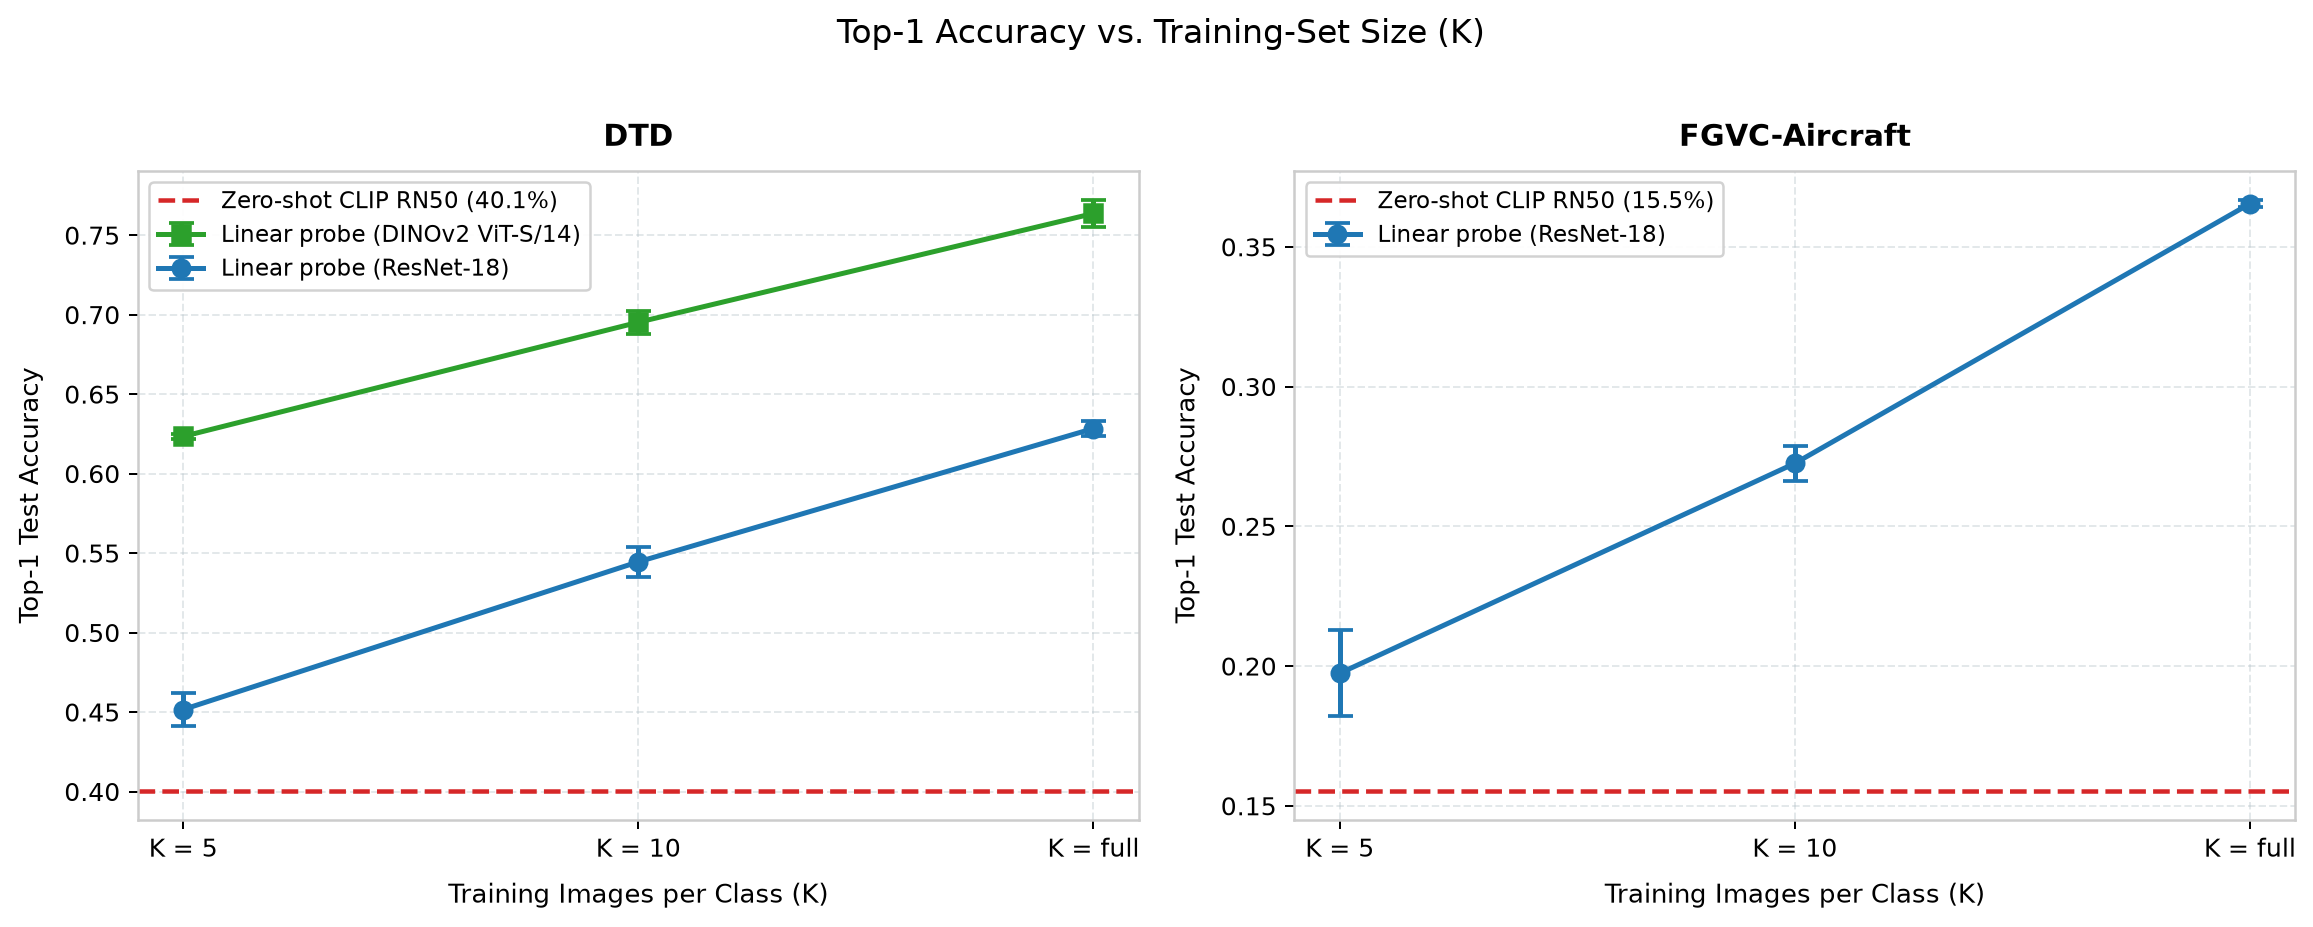

In [7]:
from src.fmlayer.viz.accuracy import plot_combined_accuracy_vs_k

plot_combined_accuracy_vs_k(table)

### 6.3 Linear Probe Training Curves

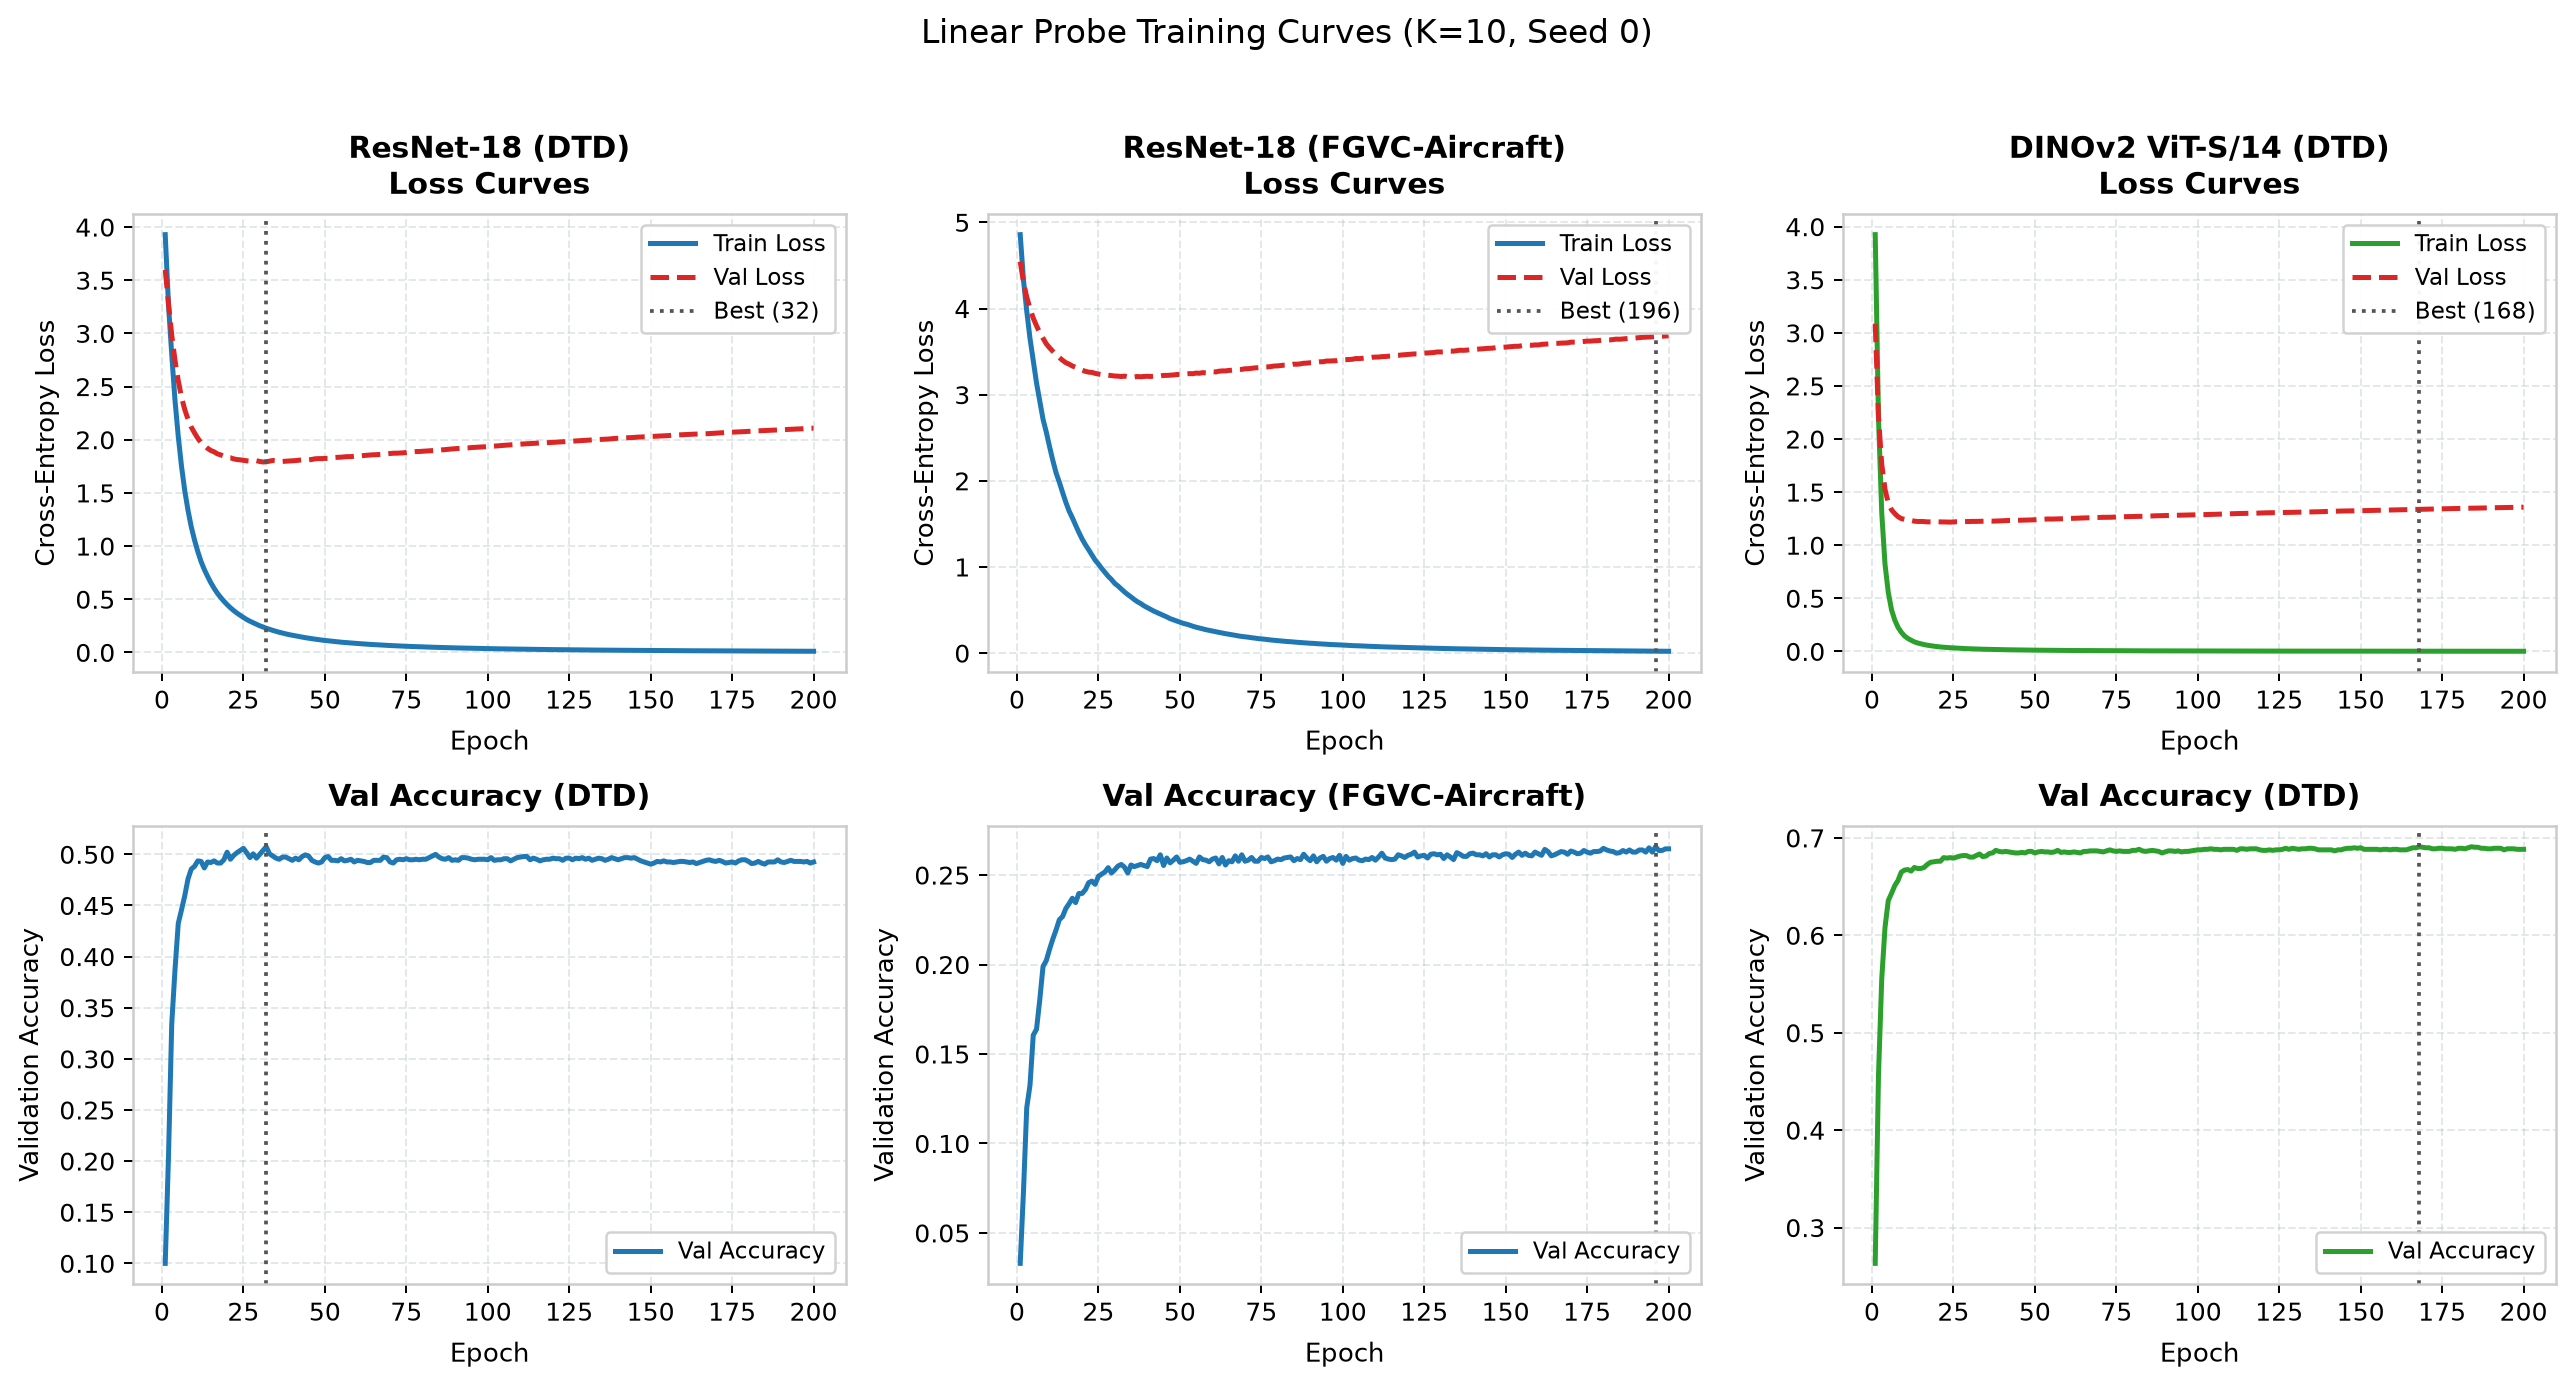

In [8]:
from src.fmlayer.viz.curves import plot_combined_curves

plot_combined_curves(k=10, seed=0)

### 6.4 Confusion Matrices

[DTD] zero-shot CLIP RN50: 0.4005 top-1 on 1880 test images
    prompt example: 'a photo of a banded texture'
[FGVC-Aircraft] zero-shot CLIP RN50: 0.1554 top-1 on 3333 test images
    prompt example: 'a photo of a 707-320 aircraft'


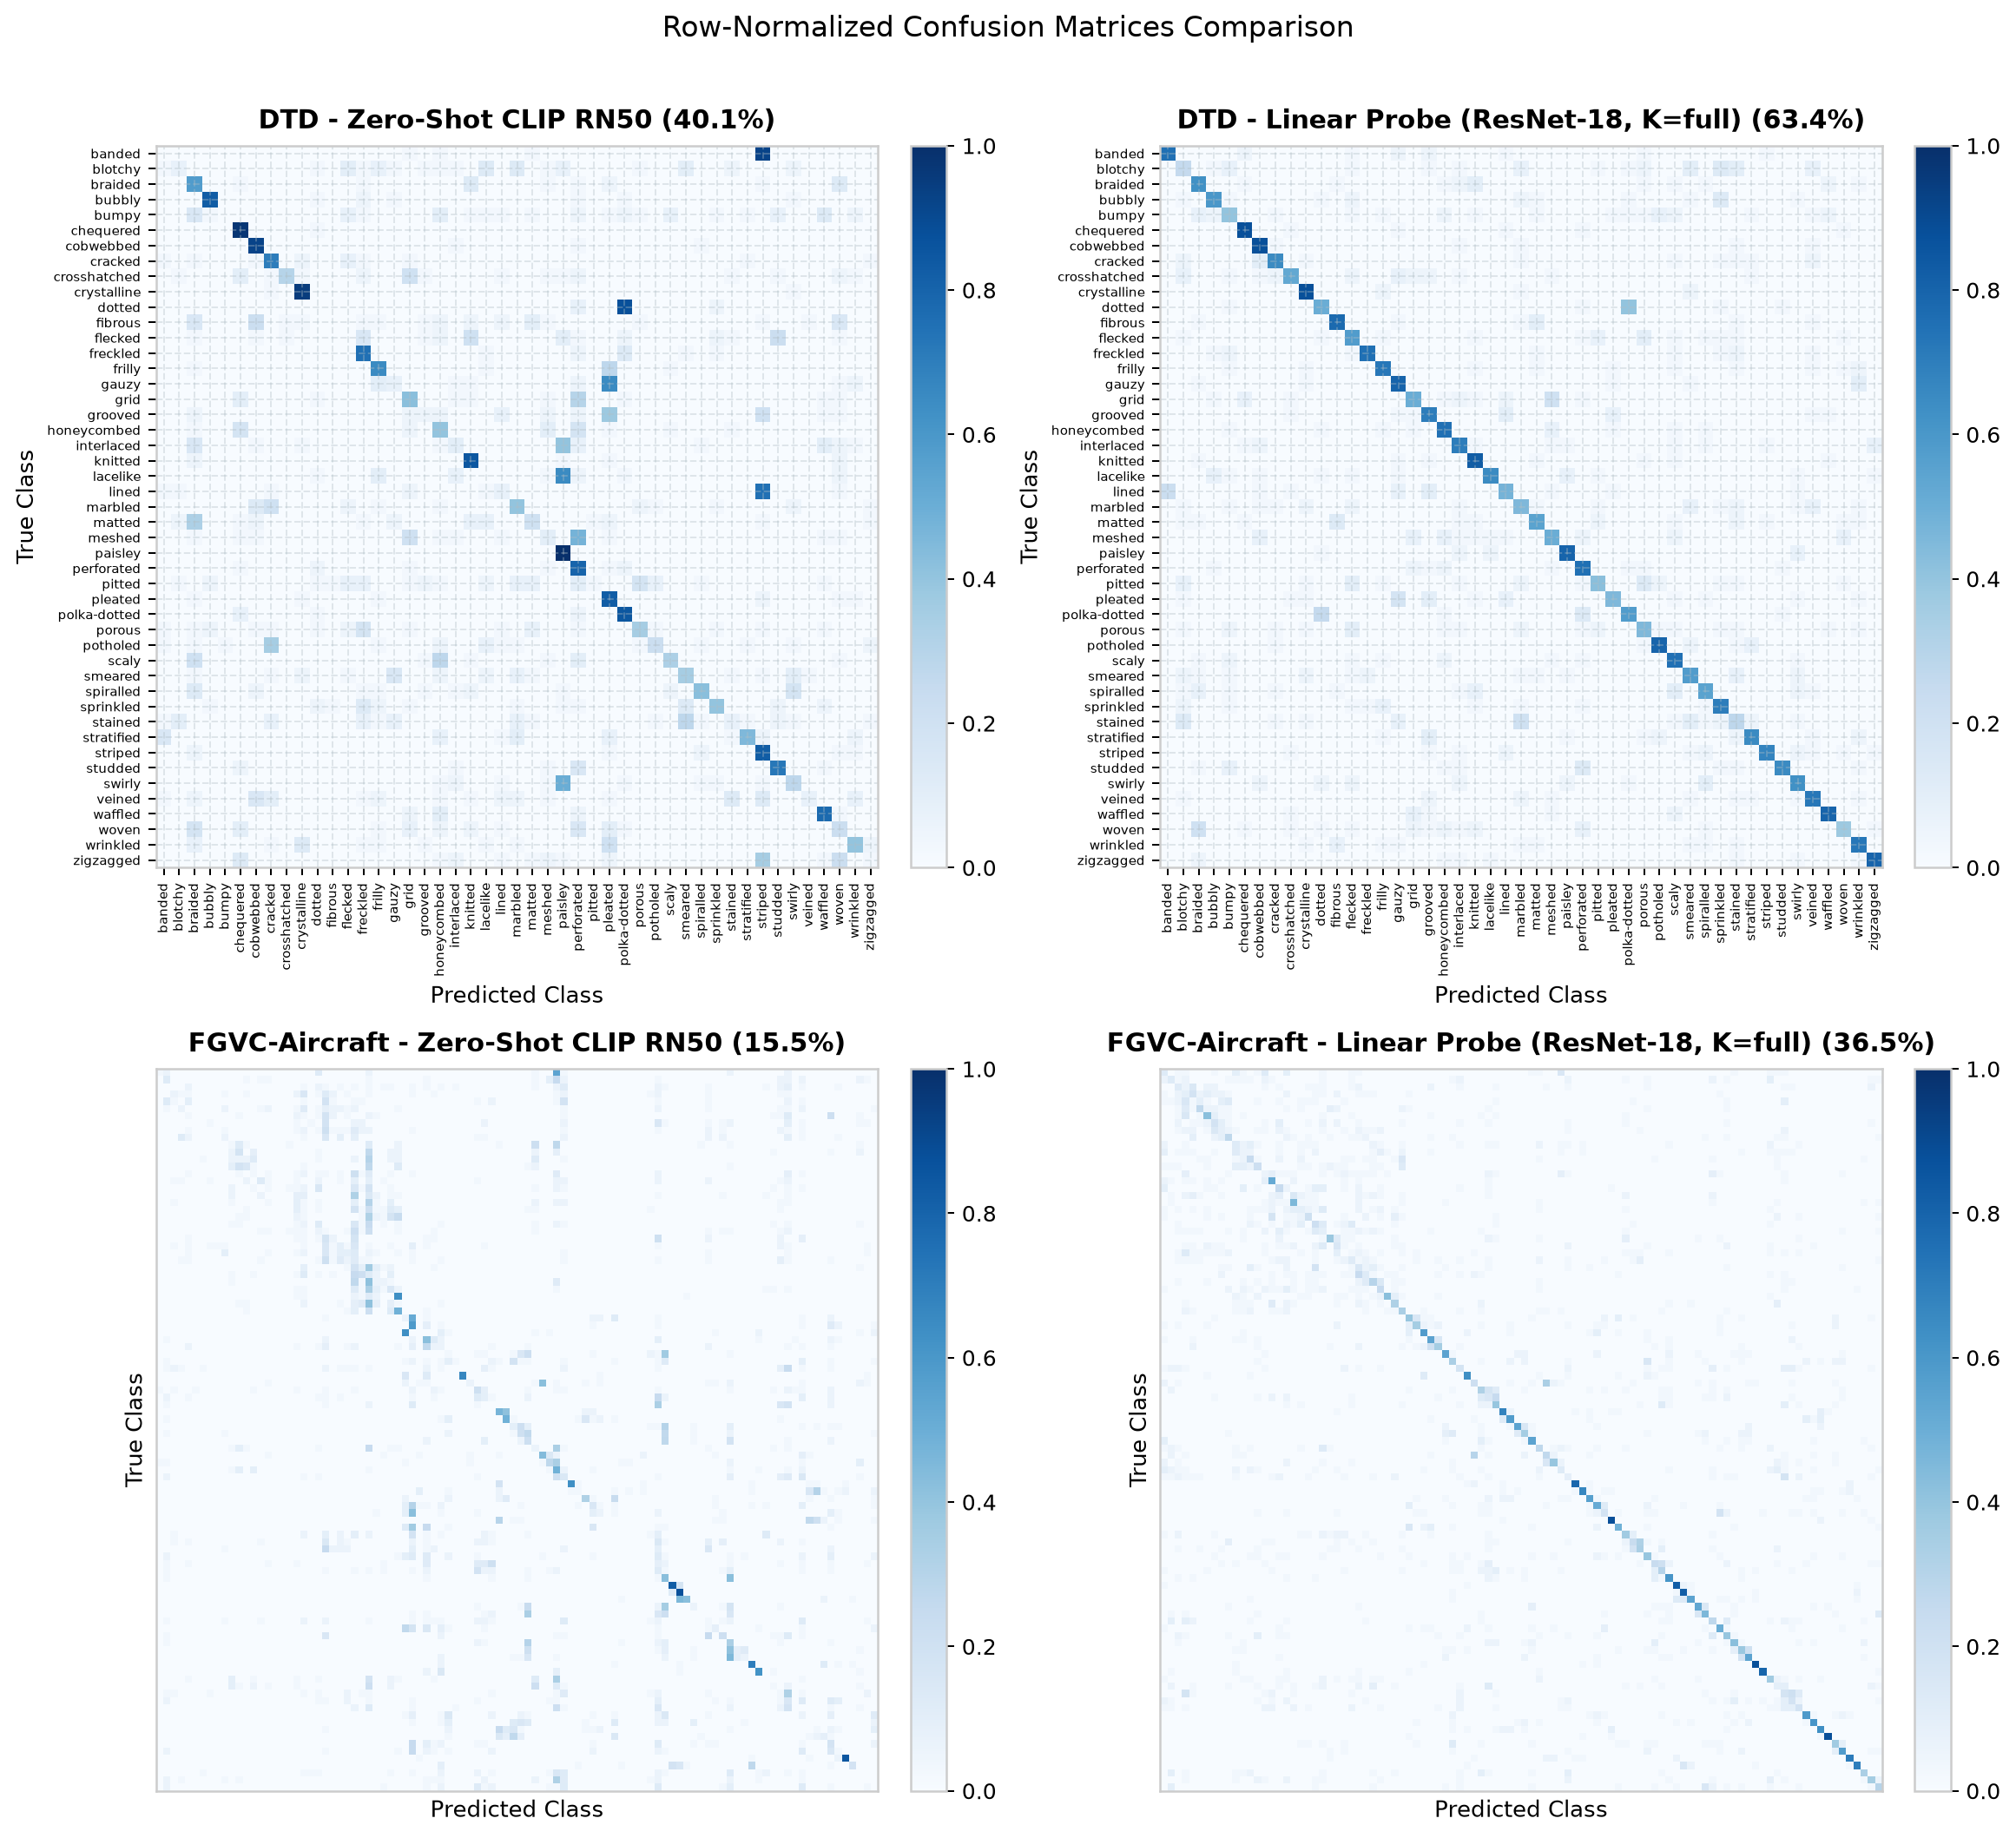

In [9]:
from src.fmlayer.viz.confusion import plot_combined_confusion

plot_combined_confusion(k="full", seed=0)

### 6.5 2D Feature Visualizations (PCA & t-SNE)

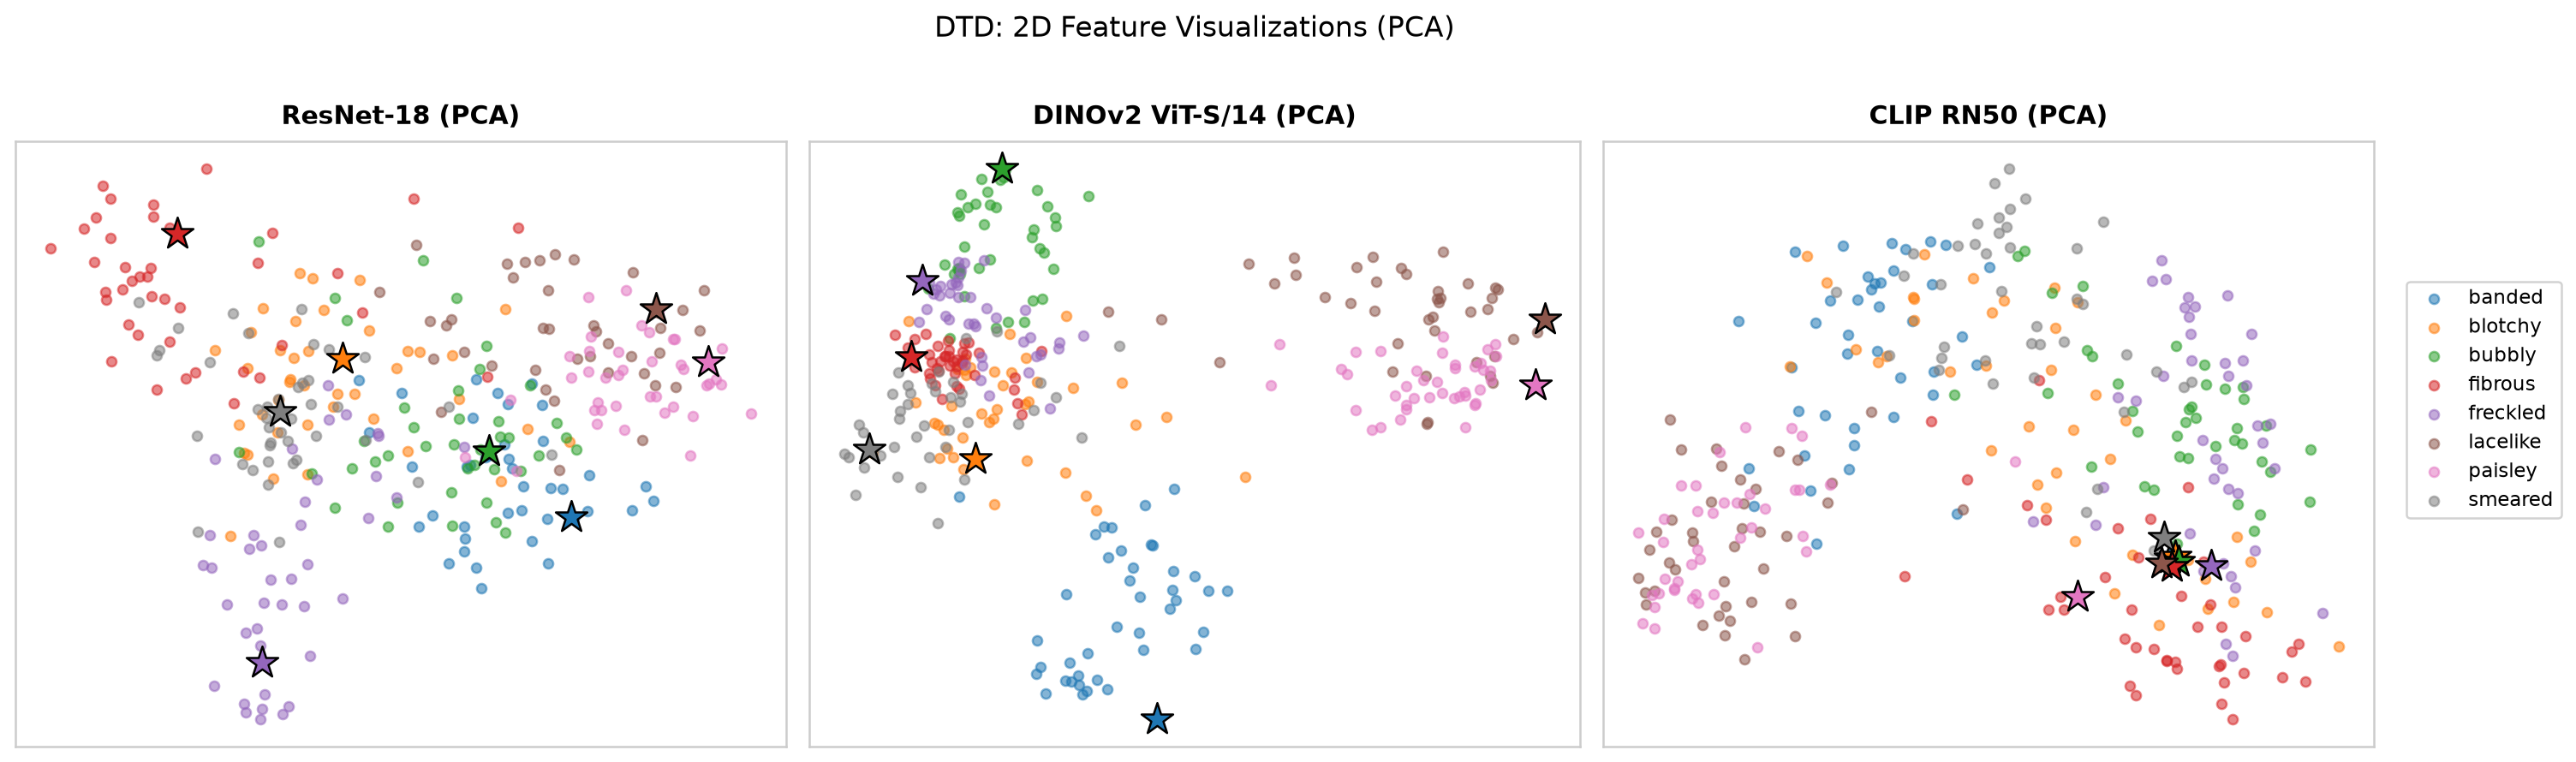

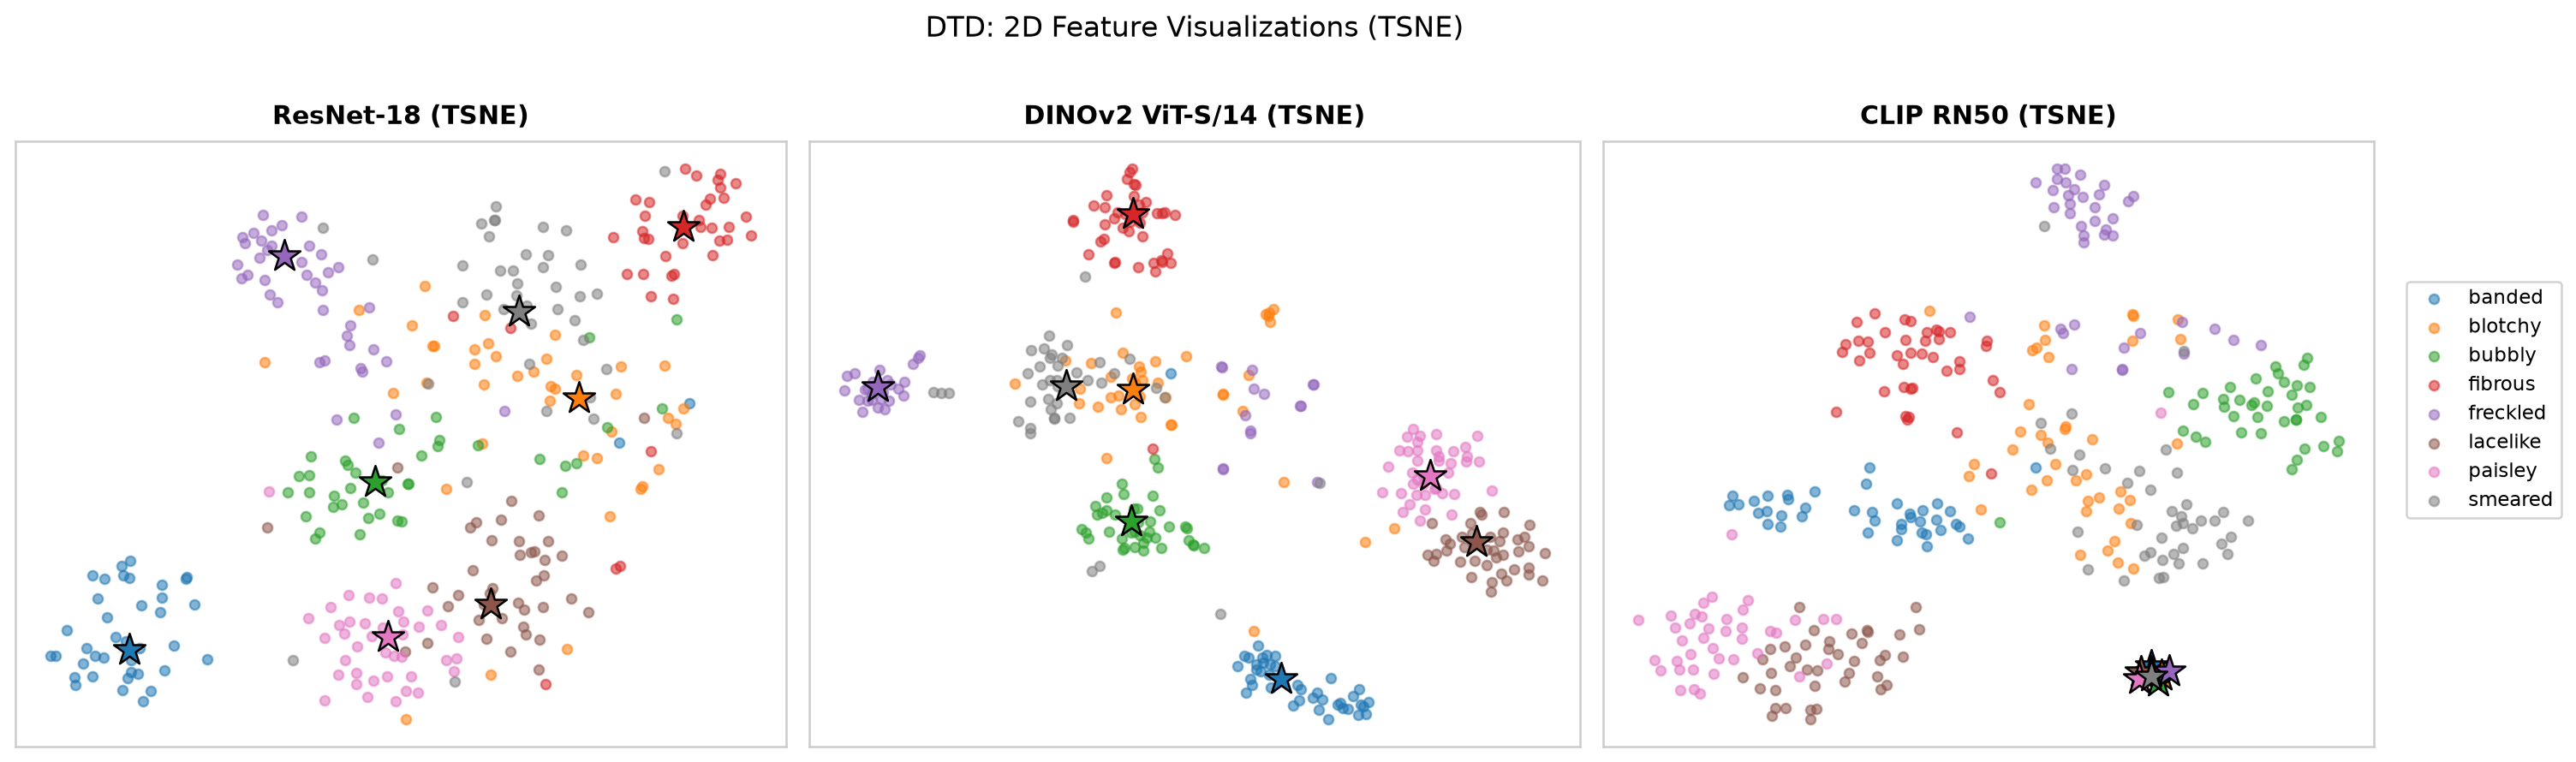

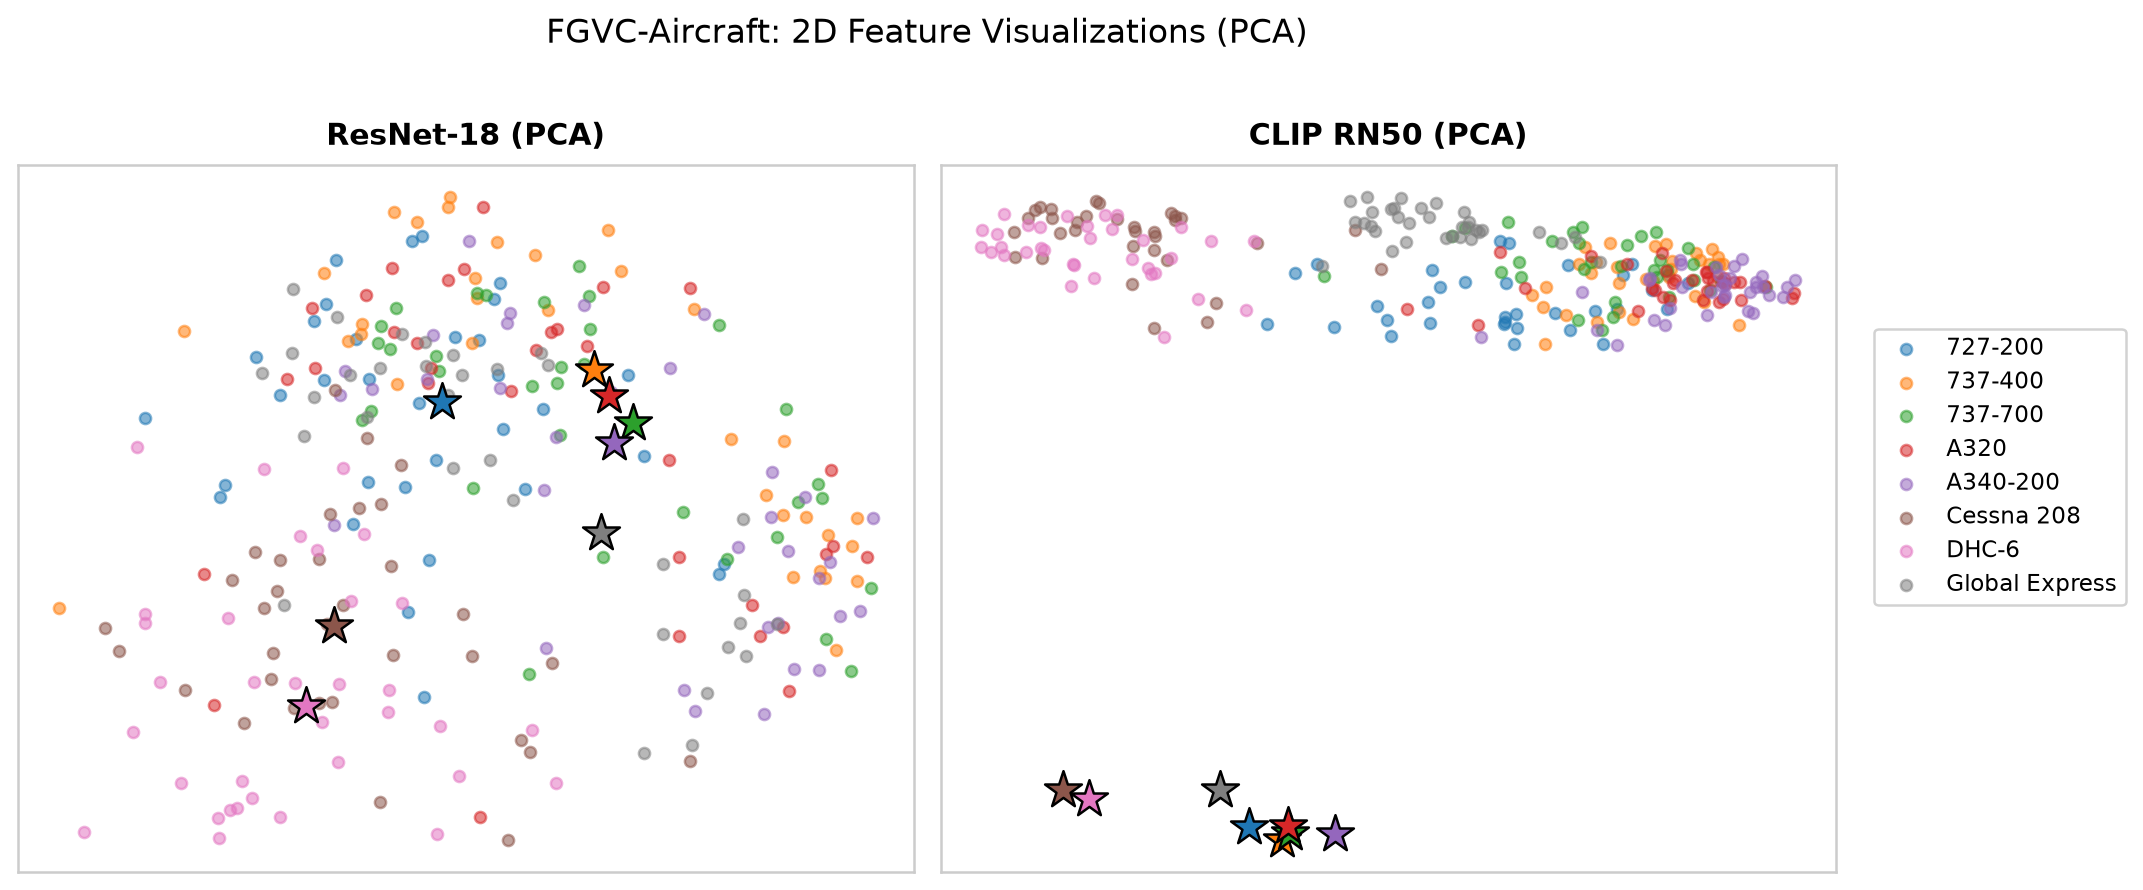

In [10]:
from src.fmlayer.viz.embeddings import plot_combined_embeddings_for_dataset

plot_combined_embeddings_for_dataset("dtd", method="pca")
plot_combined_embeddings_for_dataset("dtd", method="tsne")
plot_combined_embeddings_for_dataset("aircraft", method="pca")